# Replay analysis — one Kaggle episode

Parses replay JSON from `kaggle_logs/<submission_id>/replays/` (both players' private state + actions).

Batch summary for all episodes in a submission:

```bash
scripts/summarize_replays.sh <submission_id> --us-name "Your Name"
# writes kaggle_logs/<submission_id>/<submission_id>.json

cd scripts && python -m replay_analysis ../kaggle_logs/<submission_id> --us-name "Your Name"
```

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

from replay_analysis import (
    analyze,
    plot_earnings_by_day,
    plot_earnings_by_zone,
    plot_game,
    plot_worker_actions,
)

SUBMISSION_ID = "56251213"
EPISODE_ID = "109724541"  # from episodes.csv or replay filename
US_NAME = "Milos Vlainic"  # optional; matches info.TeamNames

REPLAY = ROOT / f"kaggle_logs/{SUBMISSION_ID}/replays/episode-{EPISODE_ID}-replay.json"
print(REPLAY, REPLAY.exists())

/media/wlaki/W/DS_projects/Kaggle/kaggriculture/kaggle_logs/56251213/replays/episode-109724541-replay.json True


In [8]:
report = analyze(REPLAY, us_name=US_NAME)
print(
    f"episode={report['episode_id']} seed={report['seed']} "
    f"rewards={report['rewards']} us_index={report['us_index']}"
)
us = report["us_index"] or 0
print(f"PASS total: {report['passes']['by_player'][us]['total']}")
print(f"Sold (filled): {report['sells']['by_player'][us]['filled_units']}")
print(f"End shed: {report['shed_end']['by_player'][us]['combined']}")

episode=109724541 seed=373904160 rewards=[131267.0, 41876.0] us_index=1
PASS total: 1302
Sold (filled): {'WHEAT': 167, 'FERTILIZER': 184, 'CARROT': 73, 'EGG': 293, 'TOMATO': 13, 'MILK': 60, 'MELON': 36, 'WOOL': 18, 'STRAWBERRY': 10}
End shed: {'FERTILIZER': 6, 'EGG': 6, 'WHEAT': 56, 'WOOL': 4, 'CARROT': 17, 'MELON': 6, 'MILK': 3}


/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/replay_analysis/plot.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


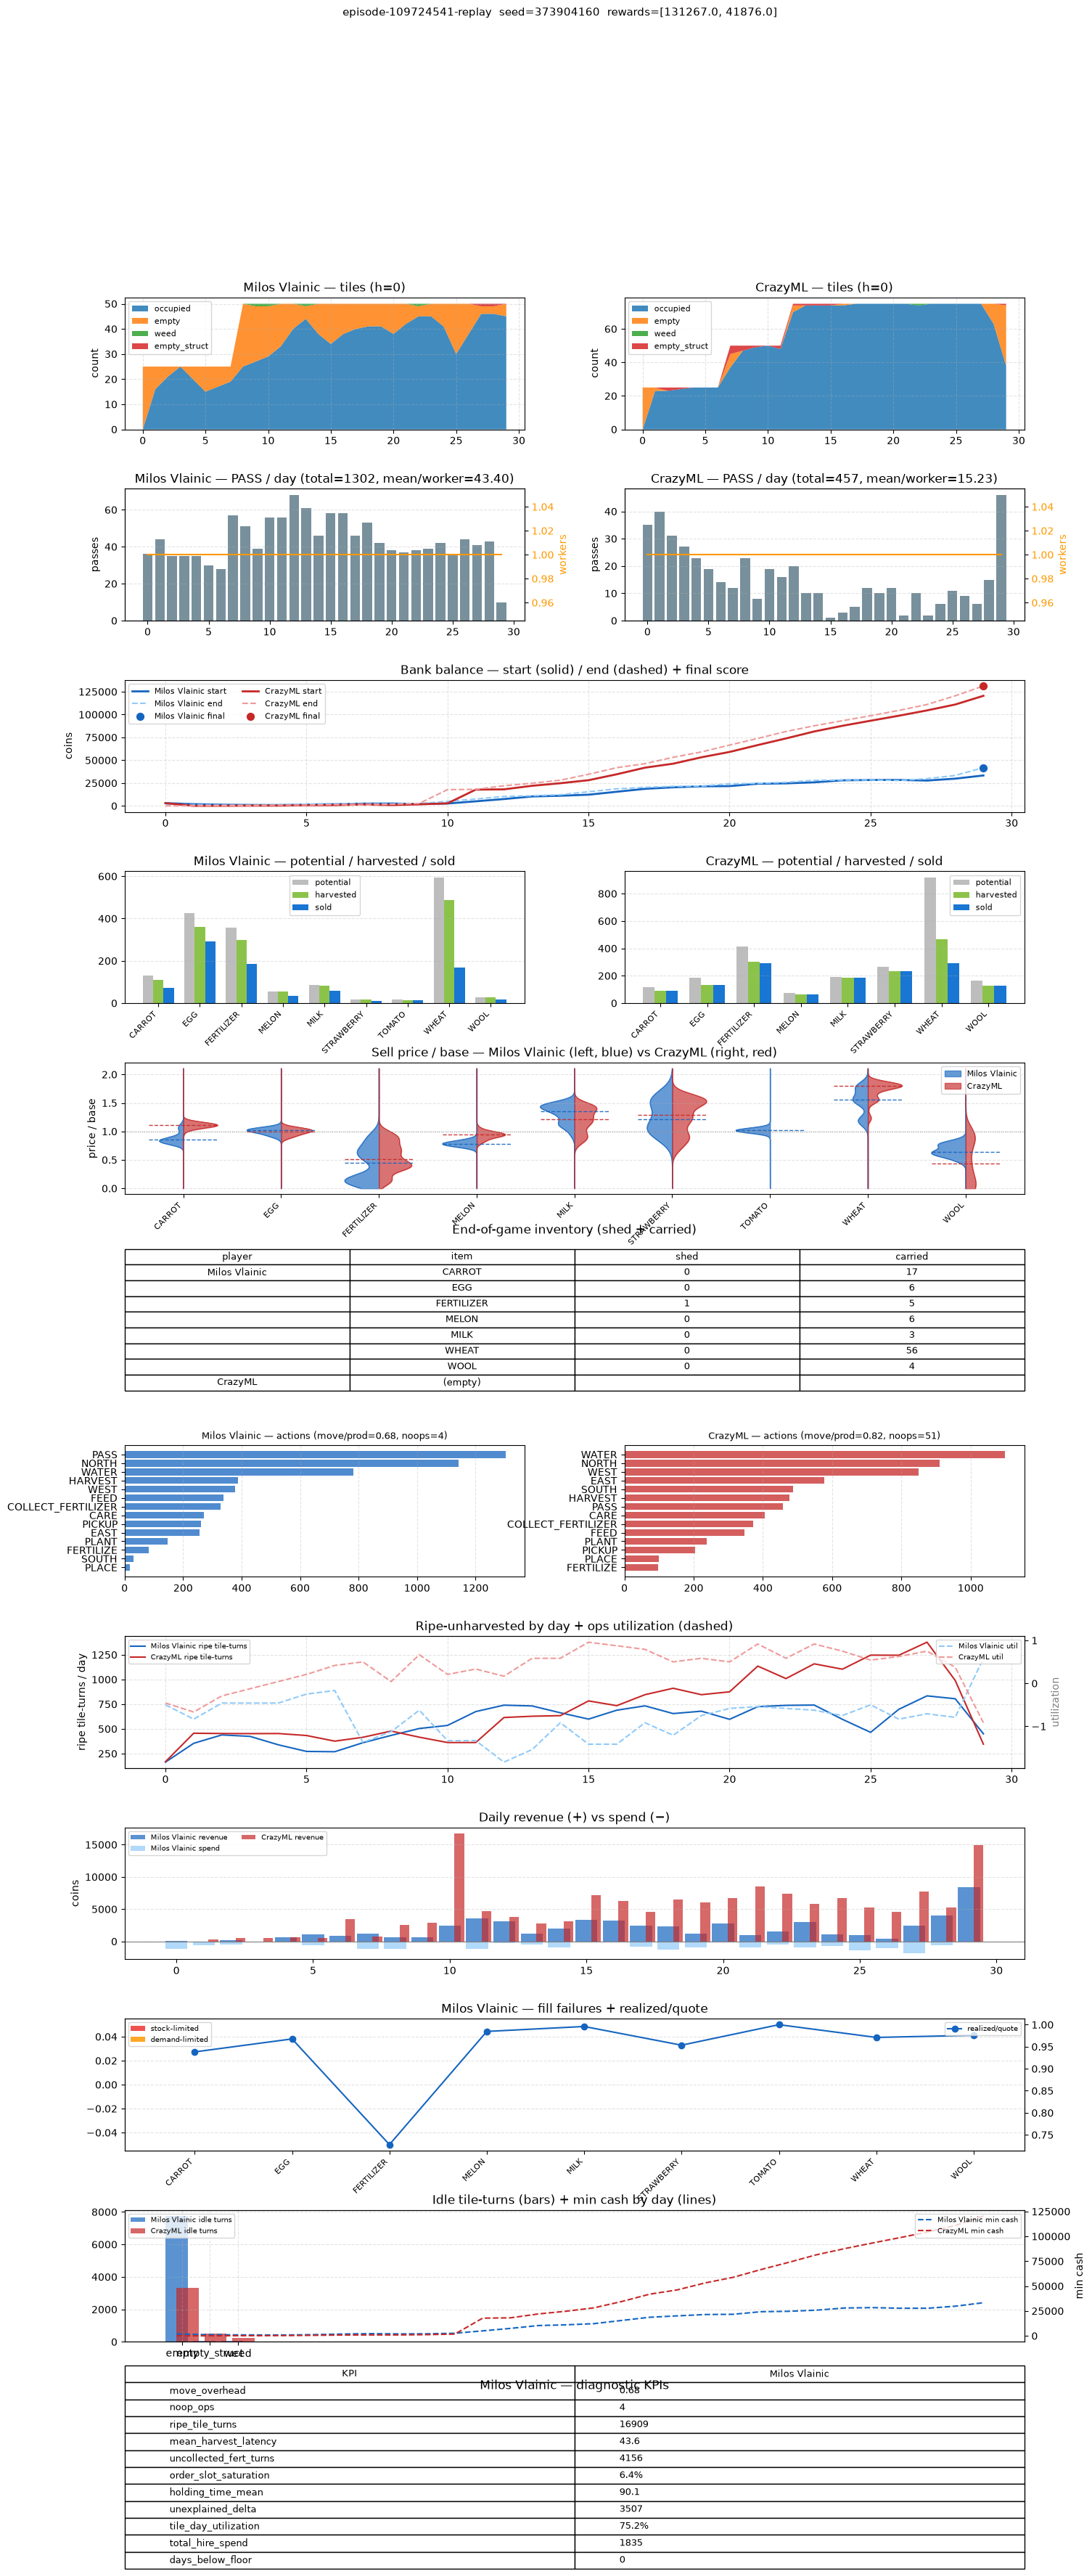

In [9]:
plot_game(report)

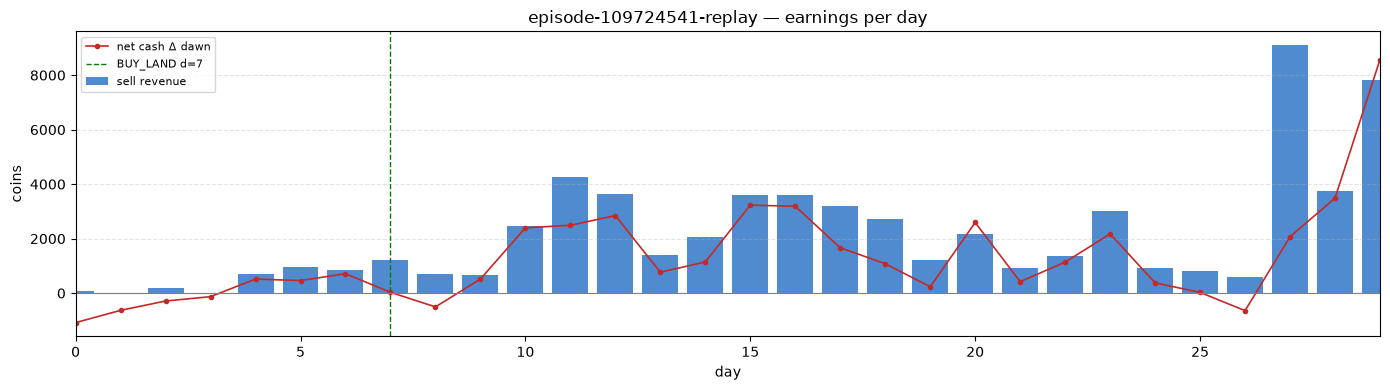

In [10]:
plot_earnings_by_day(report)

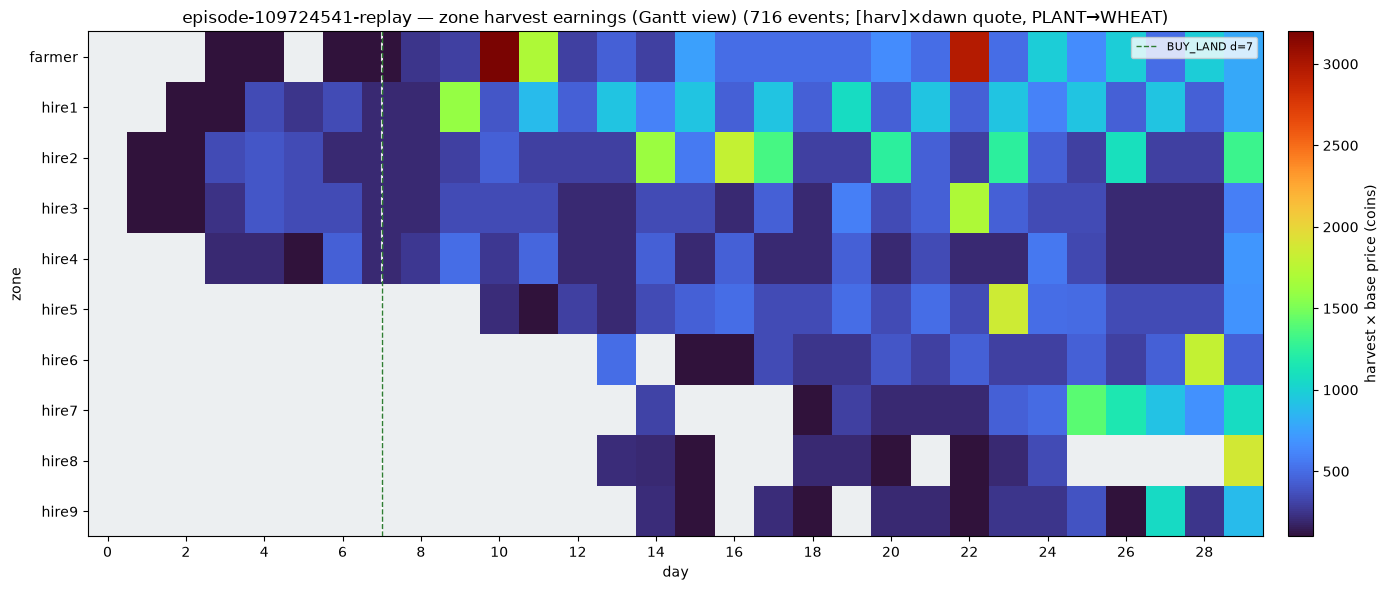

In [11]:
plot_earnings_by_zone(report)

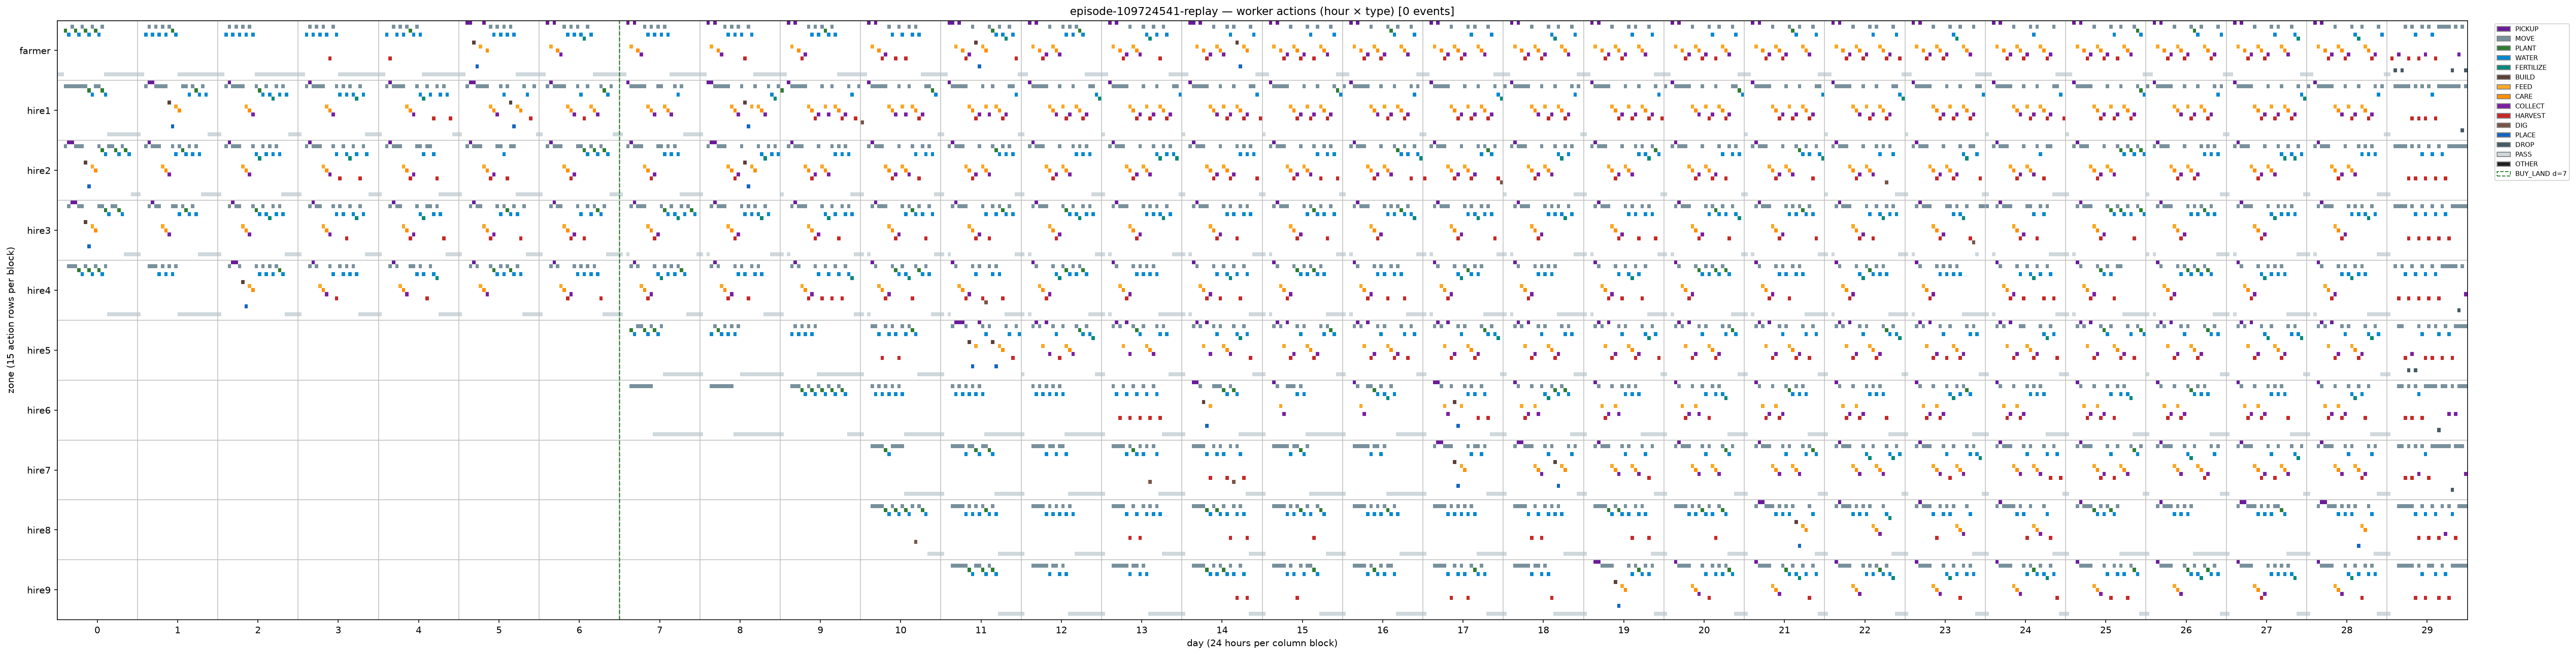

In [12]:
plot_worker_actions(report)